In [2]:
import os
import gc
import torch
# 1. Force PyTorch to see only the primary GPU (prevents DataParallel wrapping)
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# Clear memory cache
gc.collect()
torch.cuda.empty_cache()

In [1]:
# kaggle notebook relies on upgrading these dependencies
!pip install --upgrade "torchao>=0.16.0" "transformers[torch]" accelerate peft datasets scipy scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 38.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.9/832.9 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 52.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 67.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 46.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 71.3 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.

In [3]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer, util

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


In [22]:
#from google.colab import drive
#drive.mount('/content/drive')




In [7]:
path = "/kaggle/input/datasets/quora/question-pairs-dataset/questions.csv"
from pathlib import Path

path = Path(path)
df = pd.read_csv(path)

In [24]:
df

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0
...,...,...,...,...,...,...
404346,404346,789792,789793,How many keywords are there in the Racket prog...,How many keywords are there in PERL Programmin...,0
404347,404347,789794,789795,Do you believe there is life after death?,Is it true that there is life after death?,1
404348,404348,789796,789797,What is one coin?,What's this coin?,0
404349,404349,789798,789799,What is the approx annual cost of living while...,I am having little hairfall problem but I want...,0


In [25]:
import numpy as np
import torch
import torch.nn.functional as F

def compute_accuracy(model, df, batch_size=32):  # Reduced batch size for 278M param model
    print("Computing accuracy...")
    print(f"Number of question pairs: {len(df)}")
    
    thresholds = np.arange(0.5, 1.0, 0.05)
    questions1 = df["question1"].fillna("").astype(str).tolist()
    questions2 = df["question2"].fillna("").astype(str).tolist()

    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Disable gradient tracking explicitly to free VRAM
    with torch.no_grad():
        emb1 = model.encode(
            questions1,
            convert_to_tensor=True,
            show_progress_bar=True,
            batch_size=batch_size,
        ).to(device)

        emb2 = model.encode(
            questions2,
            convert_to_tensor=True,
            show_progress_bar=True,
            batch_size=batch_size,
        ).to(device)

        # 1. Normalize unit vectors
        emb1_norm = F.normalize(emb1, p=2, dim=1)
        emb2_norm = F.normalize(emb2, p=2, dim=1)

        # 2. Element-wise row dot products
        cosine_scores = torch.sum(emb1_norm * emb2_norm, dim=1).cpu().numpy()

    true_labels = df["is_duplicate"].values
    accuracy = []

    for threshold in thresholds:
        predictions = (cosine_scores >= threshold).astype(int)
        accuracy.append(np.mean(predictions == true_labels))

    return accuracy, thresholds

In [26]:
model = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')
accuracy = compute_accuracy(model, df)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/723 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Computing accuracy...
Number of question pairs: 404351


Batches:   0%|          | 0/12636 [00:00<?, ?it/s]

Batches:   0%|          | 0/12636 [00:00<?, ?it/s]

In [27]:
accuracy, thresholds = accuracy

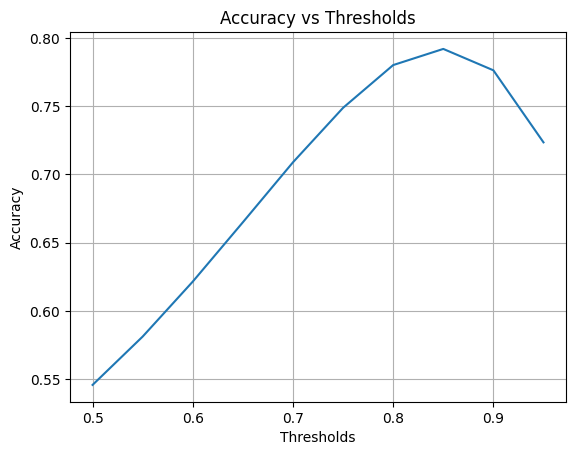

In [28]:
import matplotlib.pyplot as plt

plt.plot(thresholds, accuracy)
plt.xlabel('Thresholds')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Thresholds')
plt.grid()
plt.show()

In [9]:
loc1 = '/kaggle/input/datasets/iyanuokinbaloye/jamb-question-data/math_jamb_siamese_mixed_duplicates.csv'
loc2 = '/kaggle/input/datasets/iyanuokinbaloye/jamb-question-data/physics_jamb_siamese_mixed_duplicates.csv'
loc3 = '/kaggle/input/datasets/iyanuokinbaloye/jamb-question-data/biology_jamb_contrast_rich_final.csv'
loc4 = '/kaggle/input/datasets/iyanuokinbaloye/jamb-question-data/chemistry_jamb_contrast_dataset_clean_v4.csv'
loc5 = '/kaggle/input/datasets/iyanuokinbaloye/jamb-question-data/jamb_math_contrast_dataset_2000.csv'

path1 = Path(loc1)
path2 = Path(loc2)
path3 = Path(loc3)
path4 = Path(loc4)
path5 = Path(loc5)

df1 = pd.read_csv(path1)
print(display(df1))

df2 = pd.read_csv(path2)
print(display(df2))

df3 = pd.read_csv(path3)
print(display(df3))

df4 = pd.read_csv(path4)
print(display(df4))

df5 = pd.read_csv(path5)



,qid,question1,question2,is_duplicate
0,0,A construction company is owned by two partner...,A software company owned by partners A and B a...,1
1,1,If M represents the median and D the mode of t...,"Using the information given, if M represents t...",1
2,2,"Given a regular hexagon, calculate each interi...","From the data provided, given a regular hexago...",1
3,3,Solve the following equations 4x – 3 = 3x + y ...,"Based on the conditions stated, solve the foll...",1
4,4,If x = 1 is root of the equation x3 – 2x2 – 5x...,Consider the problem where if x = 1 is root of...,1
...,...,...,...,...
3996,3996,Peter’s weekly wages are #20.00 for the first ...,"If the scores of 3students in a test are 5,6 a...",0
3997,3997,"The variance of the scores 1,2,3,4,5 is",Find the area bounded by the curves y = 4 – x2,0
3998,3998,"In XYZ above, determine the cosine of angle Z","If (x - 1), (x + 1) and (x - 2) are factors of...",0
3999,3999,"Find the equation of the locus of a point P(x,...",Find the range of values of x for which x + 2/...,0


None


,qid,question1,question2,is_duplicate
0,0,"In a resonance tube experiment, a tube of fixe...",Determine the result for the following: in a r...,1
1,1,Which of the following is NOT a vector quantity,Which option below is NOT a vector quantity,1
2,2,P1 P3 O O3 O2 P2 the figure Consider the three...,"Using the information given, p1 P3 O O3 O2 P2 ...",1
3,3,Cord Pull the figure A brick at rest on a hori...,Consider the following problem: cord Pull the ...,1
4,4,The force with which an object is attracted to...,Determine the force with which an object is at...,1
...,...,...,...,...
3996,3996,Equal masses of copper and rubber are raised t...,Which of the following correctly represents th...,0
3997,3997,What happens when a certain quantity of pure i...,The heat produced in a conductor carrying an e...,0
3998,3998,Download MySchoolGist JAMB CBT Software from h...,The resistances of a platinum wire at the ice ...,0
3999,3999,Which of the following pairs is NOT part of th...,If a ray traveling in air is incident on a tra...,0


None


,qid,question1,question2,is_duplicate
0,0,The sex of a foetus is determined during,When is the sex of a foetus established?,1
1,1,The part labelled II is the,The most important environmental factor which ...,0
2,2,Most monocots are easily recognized by their,The villus in the small intestine is significa...,0
3,3,The function of the long-winged reproductives ...,There will be agglutination when the,0
4,4,The end products of the digestion of fats and ...,Which simpler substances result from digestion...,1
...,...,...,...,...
995,995,When a healthy shoot of a flowering plant is i...,A flowering plant is monoecious if,0
996,996,If the phloem of a healthy plant is killed by ...,Fossil records found in sedimentary rocks offe...,0
997,997,The gas occupying the space labelled I is,What is gas occupying the space labelled I?,1
998,998,The main organic substances found in the human...,What are the principal organic substances pres...,1


None


,qid,question1,question2,is_duplicate
0,0,How many coulombs of electricity are passed th...,Determine the number of coulombs of electricit...,1
1,1,Which of the following hydrogen halides has th...,Crudepetroleum pollutant usuallyseen on some N...,0
2,2,The number of atom chlorine present in 5.85 g ...,The solubilityproduct of Cu(lO3 )2 is 1.08 x 1...,0
3,3,Which of the following compounds is NOT formed...,Which compounds fails to formed by the action ...,1
4,4,The phenomenon whereby sodium trioxocarbonate ...,What term is used for The phenomenon whereby s...,1
...,...,...,...,...
637,637,Which of the following solution will conduct t...,Calculate the solution that will conduct the l...,1
638,638,Some copper (11) sulphate pentahydrate (CuSO4 ...,Some zinc (11) sulphate pentahydrate (CuSO4 5H...,0
639,639,How many valence electrons are contained in th...,Determine the number of valence electrons that...,1
640,640,Which of the following sulphides is insoluble ...,Calculate the sulphide that is insoluble in di...,1


None


In [13]:
df_final = pd.concat([df1, df2], ignore_index=True)
df_final = pd.concat([df_final, df3], ignore_index=True)
df_final = pd.concat([df_final, df4, df5], ignore_index=True)
df_final.isnull().sum()

qid             0
question1       0
question2       0
is_duplicate    0
dtype: int64

In [14]:
df_final.duplicated().sum()
df_final = df_final.drop_duplicates().reset_index()

In [17]:
np.random.seed(42)
indices = np.random.randint(0, high=404000, size=12000)
df3 = df.iloc[indices]
df3 = df3.reset_index()
df3 = df3.drop(columns=['id', 'index'])
df3

,qid1,qid2,question1,question2,is_duplicate
0,241680,241681,What are some questions to ask a girl you like?,What questions should I ask to girls?,0
1,290598,290599,I just had a very bad break up. My boyfriend l...,What did you do when your ex moved on?,0
2,261309,261310,Does Quora form intellectual bubbles?,Who owns the intellectual property of Quora?,0
3,716079,716080,What is the superstition behind a twitching ri...,What is the superstition of the lower left eye...,1
4,510083,510084,If universe is expanding without a limit and d...,How is dark/vacuum energy created with the uni...,1
...,...,...,...,...,...
11995,590580,590581,How easy or tough is it for an international s...,My mind is fucked after learning the law of at...,0
11996,40245,40246,How do I get incoming and outgoing call detail...,How do get my incoming postpaid call details?,0
11997,557703,557704,How does the ban on 500 and 1000 rupee notes h...,Would banning notes of denominations 500 and 1...,1
11998,689166,689167,How do you find meaning in what you do with yo...,What do you think about finding meaning in life?,1


In [18]:
df_final2 = pd.concat([df_final, df3], ignore_index=True).drop_duplicates().reset_index()

df_final2 = df_final2.drop(columns=['level_0', 'qid', 'index', 'qid1', 'qid2'])

df_final2


,question1,question2,is_duplicate
0,A construction company is owned by two partner...,A software company owned by partners A and B a...,1
1,If M represents the median and D the mode of t...,"Using the information given, if M represents t...",1
2,"Given a regular hexagon, calculate each interi...","From the data provided, given a regular hexago...",1
3,Solve the following equations 4x – 3 = 3x + y ...,"Based on the conditions stated, solve the foll...",1
4,If x = 1 is root of the equation x3 – 2x2 – 5x...,Consider the problem where if x = 1 is root of...,1
...,...,...,...
23458,How easy or tough is it for an international s...,My mind is fucked after learning the law of at...,0
23459,How do I get incoming and outgoing call detail...,How do get my incoming postpaid call details?,0
23460,How does the ban on 500 and 1000 rupee notes h...,Would banning notes of denominations 500 and 1...,1
23461,How do you find meaning in what you do with yo...,What do you think about finding meaning in life?,1


In [20]:
df_final2.isnull().sum()

question1       0
question2       0
is_duplicate    0
dtype: int64

In [21]:
import os
import re
import torch
from datasets import Dataset
from peft import LoraConfig, get_peft_model, TaskType
from transformers import AutoModel, AutoTokenizer

# 1. Text normalization function (Safe for Yoruba diacritics and STEM)
def normalize_math_text(text):
    text = str(text).lower()
    operators = [r"\+", r"-", r"–", r"=", r"\*", r"/", r"÷"]
    for op in operators:
        text = re.sub(f"({op})", r" \1 ", text)
    return re.sub(r"\s+", " ", text).strip()

# Apply normalization directly
df_final2['question1'] = df_final2['question1'].fillna("").apply(normalize_math_text)
df_final2['question2'] = df_final2['question2'].fillna("").apply(normalize_math_text)

# 2. Multilingual Model Configuration
model_id = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
tokenizer = AutoTokenizer.from_pretrained(model_id)
base_model = AutoModel.from_pretrained(model_id)

# 3. Configure LoRA for XLM-RoBERTa architecture
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=['query', 'value'],  # Target attention projections in XLM-RoBERTa
    bias='none',
    task_type=TaskType.FEATURE_EXTRACTION  # Native PEFT task for AutoModel feature extraction
)

# 4. Inject adapters FIRST, then move entire architecture to GPU
model = get_peft_model(base_model, lora_config)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

model.print_trainable_parameters()

config.json:   0%|          | 0.00/723 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/402 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

trainable params: 589,824 || all params: 278,633,472 || trainable%: 0.2117


In [22]:
# I really need to take that huggingface course to fully understand how the dataset module works why it returns dicts etc
# And how automodel, autoseq2seqlm etc draw the model and what params are to be passed into pefts LoraConfig
raw_dataset = Dataset.from_pandas(df_final2)

def tokenize_function(data):
    tok1 = tokenizer(
        data['question1'],
        padding='max_length',
        truncation=True,
        max_length=128,
    )
    tok2 = tokenizer(
        data['question2'],
        padding='max_length',
        truncation=True,
        max_length=128,
    )
    return {
        "input_ids1": tok1["input_ids"],
        "attention_mask1": tok1["attention_mask"],
        "input_ids2": tok2["input_ids"],
        "attention_mask2": tok2["attention_mask"],
        "labels": data["is_duplicate"],
    }

# 1. Map tokenization across dataset
tokenized_dataset = raw_dataset.map(tokenize_function, batched=True)

# 2. Split into DatasetDict ('train' and 'test')
tokenized_datasets = tokenized_dataset.train_test_split(test_size=0.1, seed=42)

# 3. CRITICAL: Enforce PyTorch tensor casting on your custom keys
required_columns = ["input_ids1", "attention_mask1", "input_ids2", "attention_mask2", "labels"]
tokenized_datasets.set_format(type="torch", columns=required_columns)

Map:   0%|          | 0/23463 [00:00<?, ? examples/s]

In [23]:
import os

# Define the path
output_dir = "/kaggle/working/Model2"

# Create the directory (exist_ok=True prevents errors if it already exists)
os.makedirs(output_dir, exist_ok=True)


In [24]:
import torch
import torch.nn as nn
from transformers import Trainer, TrainingArguments

class SiameseTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        input_ids1, mask1 = inputs.get("input_ids1"), inputs.get("attention_mask1")
        input_ids2, mask2 = inputs.get("input_ids2"), inputs.get("attention_mask2")
        labels = inputs.get("labels").float()

        outputs1 = model(input_ids=input_ids1, attention_mask=mask1)
        outputs2 = model(input_ids=input_ids2, attention_mask=mask2)

        emb1 = self._mean_pooling(outputs1, mask1)
        emb2 = self._mean_pooling(outputs2, mask2)

        cosine_sim = torch.cosine_similarity(emb1, emb2, dim=1)
        # Target mapping: 1 for Duplicate, -1 for Non-Duplicate
        # Convert binary labels [0, 1] -> [-1, 1]
        target = torch.where(labels == 1, 1.0, -1.0)

        loss_fct = nn.CosineEmbeddingLoss(margin=0.2)
        loss = loss_fct(emb1, emb2, target)
        return (loss, cosine_sim) if return_outputs else loss

    def prediction_step(self, model, inputs, prediction_loss_only, ignore_keys=None):
        """Overrides evaluation loop to prevent input_ids missing error during eval."""
        with torch.no_grad():
            loss, cosine_sim = self.compute_loss(model, inputs, return_outputs=True)
            
        if prediction_loss_only:
            return (loss, None, None)
            
        return (loss, cosine_sim, inputs.get("labels"))

    def _mean_pooling(self, model_output, attention_mask):
        token_embeddings = model_output.last_hidden_state
        input_mask_expanded = (
            attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        )
        sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, dim=1)
        sum_mask = torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)
        return sum_embeddings / sum_mask


# 6. Optimized System Execution Parameters
training_args = TrainingArguments(
    output_dir="/kaggle/working/Model2",
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=4,
    learning_rate=2e-4,
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    weight_decay=0.01,
    fp16=torch.cuda.is_available(),
    report_to="none",
    remove_unused_columns=False,  # CRITICAL: Retains input_ids1, input_ids2, etc.
)

# 7. Initialize and Run the Pipeline
trainer = SiameseTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
)

print("Starting custom fine-tuning execution...")
trainer.train()

Starting custom fine-tuning execution...


Epoch,Training Loss,Validation Loss
1,0.147457,0.132464
2,0.134759,0.126532
3,0.129445,0.123412
4,0.116392,0.123155


TrainOutput(global_step=2640, training_loss=0.13910552714810226, metrics={'train_runtime': 783.3204, 'train_samples_per_second': 107.828, 'train_steps_per_second': 3.37, 'total_flos': 0.0, 'train_loss': 0.13910552714810226, 'epoch': 4.0})

In [25]:
import os
import pathlib

# Define a single, unified output path
save_path = pathlib.Path("/kaggle/working/question_duplicate_model")

# Save both adapter weights and tokenizer to the same directory
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

print("Final LoRA weights and tokenizer saved successfully!")
print(os.listdir(save_path))

Final LoRA weights and tokenizer saved successfully!
['README.md', 'tokenizer_config.json', 'tokenizer.json', 'adapter_config.json', 'adapter_model.safetensors', 'training_args.bin']


In [26]:
import numpy as np
from sklearn.metrics import classification_report

# 1. Run inference across the test split
eval_results = trainer.predict(tokenized_datasets["test"])
scores = eval_results.predictions  # Predicted cosine similarities
labels = eval_results.label_ids

# 2. Sweep thresholds from 0.50 to 0.90 to maximize F1-score
best_f1, best_thresh = 0, 0.5
for thresh in np.arange(0.50, 0.90, 0.02):
    preds = (scores >= thresh).astype(int)
    report = classification_report(labels, preds, output_dict=True, zero_division=0)
    f1 = report["1"]["f1-score"]  # Focus on duplicate detection performance
    if f1 > best_f1:
        best_f1, best_thresh = f1, thresh

print(f"Optimal Cosine Threshold: {best_thresh:.2f} | Peak Duplicate F1-Score: {best_f1:.4f}")

Optimal Cosine Threshold: 0.74 | Peak Duplicate F1-Score: 0.8650


In [30]:
import torch
import numpy as np
import pandas as pd
from peft import PeftModel
from transformers import AutoModel, AutoTokenizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# 1. Path configuration & Model loading
model_path = "/kaggle/working/question_duplicate_model"
base_model_id = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"

tokenizer = AutoTokenizer.from_pretrained(model_path)
base_model = AutoModel.from_pretrained(base_model_id)

# Merge trained LoRA adapter weights with base architecture
model = PeftModel.from_pretrained(base_model, model_path)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()

# 2. Mask-aware mean pooling function
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output.last_hidden_state
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, dim=1)
    sum_mask = torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)
    return sum_embeddings / sum_mask

# 3. Batched similarity scoring function
def compute_df_similarities(df, batch_size=64):
    q1_list = df['question1'].astype(str).tolist()
    q2_list = df['question2'].astype(str).tolist()
    similarities = []

    for i in range(0, len(q1_list), batch_size):
        batch_q1 = q1_list[i:i+batch_size]
        batch_q2 = q2_list[i:i+batch_size]

        tok1 = tokenizer(batch_q1, padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
        tok2 = tokenizer(batch_q2, padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)

        with torch.no_grad():
            out1 = model(**tok1)
            out2 = model(**tok2)

            emb1 = mean_pooling(out1, tok1['attention_mask'])
            emb2 = mean_pooling(out2, tok2['attention_mask'])

            cosine_sim = torch.cosine_similarity(emb1, emb2, dim=1)
            similarities.extend(cosine_sim.cpu().numpy())

    return np.array(similarities)

# 4. Run inference on DataFrame
print("Generating vector embeddings and computing cosine similarities...")
df_final2['similarity_score'] = compute_df_similarities(df_final2)
y_true = df_final2['is_duplicate'].values

# 5. Threshold sweep to determine peak Accuracy and F1-score
best_threshold = 0.50
best_threshold_f1 = 0.50
best_acc = 0.0
best_f1 = 0.0 

print("\n--- Model Accuracy Across Decision Thresholds ---")
for thresh in np.arange(0.50, 0.95, 0.05):
    preds = (df_final2['similarity_score'] >= thresh).astype(int)
    acc = accuracy_score(y_true, preds)
    f1 = f1_score(y_true, preds)
    print(f"Cosine Cutoff: {thresh:.2f} | Overall Accuracy: {acc * 100:.2f}%")
    
    if acc > best_acc:
        best_acc = acc
        best_threshold = thresh
    if f1 > best_f1:
        best_f1 = f1
        best_threshold_f1 = thresh

print(f"\n==================================================")
print(f"PEAK ACCURACY: {best_acc * 100:.2f}% at Cutoff Threshold: {best_threshold:.2f}")
print(f"==================================================")
print(f"PEAK F1: {best_f1 * 100:.2f}% at Cutoff Threshold: {best_threshold_f1:.2f}")

# 6. Detailed Classification Metrics at Optimal Cutoff
best_preds = (df_final2['similarity_score'] >= best_threshold).astype(int)
print("\nDetailed Performance Breakdown:")
print(classification_report(y_true, best_preds, target_names=["Not Duplicate (0)", "Duplicate (1)"]))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Generating vector embeddings and computing cosine similarities...

--- Model Accuracy Across Decision Thresholds ---
Cosine Cutoff: 0.50 | Overall Accuracy: 88.10%
Cosine Cutoff: 0.55 | Overall Accuracy: 88.74%
Cosine Cutoff: 0.60 | Overall Accuracy: 89.14%
Cosine Cutoff: 0.65 | Overall Accuracy: 89.53%
Cosine Cutoff: 0.70 | Overall Accuracy: 89.79%
Cosine Cutoff: 0.75 | Overall Accuracy: 89.93%
Cosine Cutoff: 0.80 | Overall Accuracy: 89.79%
Cosine Cutoff: 0.85 | Overall Accuracy: 89.26%
Cosine Cutoff: 0.90 | Overall Accuracy: 88.25%

PEAK ACCURACY: 89.93% at Cutoff Threshold: 0.75
PEAK ACCURACY: 88.15% at Cutoff Threshold: 0.70

Detailed Performance Breakdown:
                   precision    recall  f1-score   support

Not Duplicate (0)       0.93      0.90      0.91     13734
    Duplicate (1)       0.86      0.90      0.88      9729

         accuracy                           0.90     23463
        macro avg       0.90      0.90      0.90     23463
     weighted avg       0.90     

In [44]:
df

,id,qid1,qid2,question1,question2,is_duplicate,similarity_score
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0,0.119277
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0,0.626382
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0,0.678026
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0,0.131808
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0,0.063786
...,...,...,...,...,...,...,...
404346,404346,789792,789793,How many keywords are there in the Racket prog...,How many keywords are there in PERL Programmin...,0,0.362368
404347,404347,789794,789795,Do you believe there is life after death?,Is it true that there is life after death?,1,0.979840
404348,404348,789796,789797,What is one coin?,What's this coin?,0,0.706355
404349,404349,789798,789799,What is the approx annual cost of living while...,I am having little hairfall problem but I want...,0,0.122522


In [31]:
import os
import gc
import torch
from sentence_transformers import CrossEncoder, InputExample
from torch.utils.data import DataLoader



# 2. Load model explicitly on cuda:0
model_name = "xlm-roberta-base"
cross_encoder = CrossEncoder(
    model_name, 
    num_labels=2, 
    max_length=128,      # Prevents memory spikes
    device="cuda:0"      # Pins to single GPU
)

# 3. Format training samples
train_examples = [
    InputExample(
        texts=[str(row['question1']), str(row['question2'])], 
        label=int(row['is_duplicate'])
    )
    for _, row in df_final2.iterrows()
]

# 4. DataLoader & Training Loop
train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=16)

output_path = "/kaggle/working/cross_encoder_yoruba_stem"

cross_encoder.fit(
    train_dataloader=train_dataloader,
    epochs=3,
    warmup_steps=100,
    output_path=output_path,
    use_amp=True  # Enables FP16 for speed and lower VRAM usage
)

cross_encoder.save(output_path)
print("Training finished cleanly on Kaggle!")

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Step,Training Loss
500,0.434655
1000,0.283801
1500,0.254662
2000,0.207467
2500,0.202072
3000,0.191501
3500,0.157321
4000,0.151382


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training finished cleanly on Kaggle!


In [ ]:
"""import os
import pathlib
from google.colab import drive
from sentence_transformers import CrossEncoder, InputExample
from torch.utils.data import DataLoader

# 2. Define output directory as a string
output_dir = "/kaggle/working/cross_encoder_yoruba_stem"
os.makedirs(output_dir, exist_ok=True)
cross_encoder.save(output_dir)

print("Saved files in directory:")
print(os.listdir(output_dir))"""

In [33]:
from sentence_transformers import CrossEncoder
import numpy as np

loc4 = str(pathlib.Path("/kaggle/working/cross_encoder_yoruba_stem"))

# Load fine-tuned Stage 2 Cross-Encoder
reranker = CrossEncoder(loc4)

def verify_duplicates(new_question, candidate_questions, stage1_indices):
    """
    new_question: str
    candidate_questions: list of str (retrieved via Stage 1 Bi-Encoder where sim >= 0.60)
    stage1_indices: list of int (original question IDs in exam bank)
    """
    if not candidate_questions:
        return []

    # Prepare pairs for joint cross-attention
    pairs = [[new_question, cand] for cand in candidate_questions]
    
    # Compute cross-encoder probability scores (0.0 to 1.0)
    scores = reranker.predict(pairs)  
    
    # Enforce strict threshold (e.g., >= 0.85) for final duplicate flag
    CROSS_THRESHOLD = 0.85
    verified_duplicates = [
        {"question_id": stage1_indices[i], "score": float(scores[i])}
        for i in range(len(scores))
        if scores[i] >= CROSS_THRESHOLD
    ]
    
    return verified_duplicates

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [54]:
import re
import torch
import numpy as np
import scipy
from peft import PeftModel
from transformers import AutoModel, AutoTokenizer
from sentence_transformers import CrossEncoder

# ---------------------------------------------------------
# 1. Setup Models & Paths
# ---------------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

# Stage 1 Bi-Encoder Paths
stage1_path = "/kaggle/working/question_duplicate_model"
base_model_id = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"

# Stage 2 Cross-Encoder Path
stage2_path = "/kaggle/working/cross_encoder_yoruba_stem"

print("Loading Stage 1 Bi-Encoder...")
tokenizer = AutoTokenizer.from_pretrained(stage1_path)
base_model = AutoModel.from_pretrained(base_model_id)
bi_encoder = PeftModel.from_pretrained(base_model, stage1_path).to(device) # when you save trainer model, its the LoRA weights that are saved so we can use get peft model to merge it to the base model from the hub
bi_encoder.eval() 

print("Loading Stage 2 Cross-Encoder...")
cross_encoder = CrossEncoder(str(stage2_path))
print(cross_encoder.config.id2label)

# ---------------------------------------------------------
# 2. Text Normalization Function
# ---------------------------------------------------------
def normalize_math_text(text):
    text = str(text).lower()
    operators = [r"\+", r"-", r"–", r"=", r"\*", r"/", r"÷"]
    for op in operators:
        text = re.sub(f"({op})", r" \1 ", text)
    return re.sub(r"\s+", " ", text).strip()

def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output.last_hidden_state
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, dim=1)
    sum_mask = torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)
    return sum_embeddings / sum_mask

# ---------------------------------------------------------
# 3. Test Cases Configuration
# ---------------------------------------------------------
raw_new_question = "Find the roots of the quadratic equation 2x^2 - 5x + 3 = 0."

candidates = [
    {"id": 101, "text": "Solve for x in 2x^2 - 5x + 3 = 0.", "expected": "Duplicate"},
    {"id": 102, "text": "Determine the values of x that satisfy the quadratic equation 2x^2 - 5x + 3 = 0.", "expected": "Duplicate"},
    {"id": 103, "text": "Find the minimum value of the function f(x) = 2x^2 - 5x + 3.", "expected": "Not Duplicate"},
    {"id": 104, "text": "Find the roots of the quadratic equation 2x^2 + 5x - 3 = 0.", "expected": "Not Duplicate"},
    {"id": 105, "text": "Calculate the derivative of sin(x) with respect to x.", "expected": "Not Duplicate"}
]

# Apply math normalization
new_q_norm = normalize_math_text(raw_new_question)
cand_texts_norm = [normalize_math_text(c["text"]) for c in candidates]

# ---------------------------------------------------------
# 4. Stage 1: Bi-Encoder Candidate Filtering
# ---------------------------------------------------------
print("\n=== RUNNING STAGE 1: Bi-Encoder Cosine Retrieval ===")

# Tokenize & encode query
q_tok = tokenizer([new_q_norm], padding=True, truncation=True, return_tensors="pt").to(device)
c_tok = tokenizer(cand_texts_norm, padding=True, truncation=True, return_tensors="pt").to(device)

with torch.no_grad():
    q_emb = mean_pooling(bi_encoder(**q_tok), q_tok['attention_mask'])
    c_embs = mean_pooling(bi_encoder(**c_tok), c_tok['attention_mask']) #batch_size, emb_size
    
    # Compute Cosine Similarities
    q_norm_vec = q_emb / torch.norm(q_emb, dim=1, keepdim=True)
    c_norm_vecs = c_embs / torch.norm(c_embs, dim=1, keepdim=True)
    stage1_scores = torch.mm(q_norm_vec, c_norm_vecs.T).squeeze(0).cpu().numpy()

stage1_candidates = []
STAGE1_THRESHOLD = 0.60
print("YES")

for idx, score in enumerate(stage1_scores):
    cand = candidates[idx]
    passed = score >= STAGE1_THRESHOLD
    print(f"Cand ID {cand['id']} | Cosine Sim: {score:.4f} | Stage 1 Filter: {'PASSED' if passed else 'REJECTED'}")
    if passed:
        stage1_candidates.append((idx, cand, score))

# ---------------------------------------------------------
# 5. Stage 2: Cross-Encoder High-Precision Verification
# ---------------------------------------------------------
print("\n=== RUNNING STAGE 2: Cross-Encoder Joint Reranking ===")

if not stage1_candidates:
    print("No candidates retrieved from Stage 1.")
else:
    # Prepare pairs passed from Stage 1
    pairs_to_verify = [[raw_new_question, cand["text"]] for _, cand, _ in stage1_candidates]
    stage2_scores = cross_encoder.predict(pairs_to_verify)
    # Softmax across axis=1 (rows)
    probs = scipy.special.softmax(stage2_scores, axis=1)
    duplicate_probs = probs[:, 1]  # Extract column 1 (Duplicate)
    print('predicted')
    
    STAGE2_THRESHOLD = 0.85
    
    print(f"\n{'ID':<6} | {'Expected':<13} | {'Stage 1 Sim':<12} | {'Stage 2 Logit/Prob':<18} | {'Final Decision':<15}")
    print("-" * 75)
    
    for i, (orig_idx, cand, s1_score) in enumerate(stage1_candidates):
        s2_score = float(duplicate_probs[i])
        is_dup = s2_score >= STAGE2_THRESHOLD
        verdict = "DUPLICATE" if is_dup else "NOT DUPLICATE"
        
        print(f"{cand['id']:<6} | {cand['expected']:<13} | {s1_score:.4f}        | {s2_score:.4f}             | {verdict:<15}")

Loading Stage 1 Bi-Encoder...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading Stage 2 Cross-Encoder...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

{0: 'LABEL_0', 1: 'LABEL_1'}

=== RUNNING STAGE 1: Bi-Encoder Cosine Retrieval ===
YES
Cand ID 101 | Cosine Sim: 0.9635 | Stage 1 Filter: PASSED
Cand ID 102 | Cosine Sim: 0.9805 | Stage 1 Filter: PASSED
Cand ID 103 | Cosine Sim: 0.7846 | Stage 1 Filter: PASSED
Cand ID 104 | Cosine Sim: 0.9996 | Stage 1 Filter: PASSED
Cand ID 105 | Cosine Sim: 0.1030 | Stage 1 Filter: REJECTED

=== RUNNING STAGE 2: Cross-Encoder Joint Reranking ===
predicted

ID     | Expected      | Stage 1 Sim  | Stage 2 Logit/Prob | Final Decision 
---------------------------------------------------------------------------
101    | Duplicate     | 0.9635        | 0.9913             | DUPLICATE      
102    | Duplicate     | 0.9805        | 0.9986             | DUPLICATE      
103    | Not Duplicate | 0.7846        | 0.0002             | NOT DUPLICATE  
104    | Not Duplicate | 0.9996        | 0.0006             | NOT DUPLICATE  


In [ ]:
"""import gc
import torch

# Delete lingering model/embedding variables if present
for var in ['bi_encoder', 'base_model', 'emb1', 'emb2', 'model']:
    if var in globals():
        del globals()[var]

gc.collect()
torch.cuda.empty_cache()

# Verify freed memory
free_mem = torch.cuda.mem_get_info()[0] / 1e9
print(f"Free VRAM: {free_mem:.2f} GB")"""

In [50]:
!pip install faiss-gpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.3/135.3 MB 13.2 MB/s eta 0:00:0000:0100:01


In [57]:
import os
import re
import enum
from typing import List, Dict, Optional, Tuple
from dataclasses import dataclass, field

import torch
import numpy as np
import faiss
import scipy.special
from peft import PeftModel
from transformers import AutoModel, AutoTokenizer
from sentence_transformers import CrossEncoder


class IngestionStatus(enum.Enum):
    APPROVED = "APPROVED"
    NEEDS_HUMAN_REVIEW = "NEEDS_HUMAN_REVIEW"
    DUPLICATE_REJECTED = "DUPLICATE_REJECTED"


@dataclass
class MatchCandidate:
    question_id: int
    question_text: str
    bi_encoder_score: float
    cross_encoder_score: Optional[float] = None


@dataclass
class IngestionResult:
    status: IngestionStatus
    question_id: Optional[int]
    question_text: str
    top_matches: List[MatchCandidate] = field(default_factory=list)


class MathTextNormalizer:
    """Preserves math operators and diacritics while standardizing whitespace."""
    @staticmethod
    def normalize(text: str) -> str:
        text = str(text).lower()
        operators = [r"\+", r"-", r"–", r"=", r"\*", r"/", r"÷"]
        for op in operators:
            text = re.sub(f"({op})", r" \1 ", text)
        return re.sub(r"\s+", " ", text).strip()


class BiEncoderEmbedder:
    """Generates 768-dim normalized embeddings using your LoRA fine-tuned model."""
    def __init__(self, base_model_id: str, adapter_path: str, device: str = None):
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        
        try:
            self.tokenizer = AutoTokenizer.from_pretrained(adapter_path)
        except Exception:
            self.tokenizer = AutoTokenizer.from_pretrained(base_model_id)
            
        base_model = AutoModel.from_pretrained(base_model_id)
        self.model = PeftModel.from_pretrained(base_model, adapter_path).to(self.device)
        self.model.eval()

    def _mean_pooling(self, model_output, attention_mask):
        token_embeddings = model_output.last_hidden_state
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, dim=1)
        sum_mask = torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)
        return sum_embeddings / sum_mask

    def encode(self, texts: List[str]) -> np.ndarray:
        norm_texts = [MathTextNormalizer.normalize(t) for t in texts]
        inputs = self.tokenizer(norm_texts, padding=True, truncation=True, max_length=128, return_tensors="pt").to(self.device)
        
        with torch.no_grad():
            outputs = self.model(**inputs)
            embeddings = self._mean_pooling(outputs, inputs['attention_mask'])
            # L2 Normalize for FAISS Inner Product (Cosine Similarity)
            norm_embeddings = torch.nn.functional.normalize(embeddings, p=2, dim=1)
            
        return norm_embeddings.cpu().numpy().astype(np.float32)


class CrossEncoderReranker:
    """High-precision Cross-Encoder for joint sequence verification."""
    def __init__(self, model_path: str, device: str = None):
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.model = CrossEncoder(model_path, device=self.device)

    def predict_duplicate_probs(self, pairs: List[Tuple[str, str]]) -> np.ndarray:
        """Computes duplicate probabilities using Softmax across logits."""
        if not pairs:
            return np.array([], dtype=np.float32)
        
        # Shape: [N, 2] for 2-class classifiers, or [N] for 1-class
        raw_logits = self.model.predict(pairs)
        
        if len(raw_logits.shape) > 1 and raw_logits.shape[1] > 1:
            # Softmax across class dimension (axis 1) and extract Class 1 (Duplicate)
            probs = scipy.special.softmax(raw_logits, axis=1)[:, 1]
        else:
            # Standard single-logit Sigmoid fallback
            probs = 1.0 / (1.0 + np.exp(-raw_logits))
            
        return probs


class ExamBankVectorStore:
    """FAISS Vector Store with 2-Stage Bi-Encoder + Cross-Encoder Gating."""
    def __init__(
        self, 
        dimension: int = 768, 
        bi_encoder_threshold: float = 0.60,
        cross_encoder_threshold: float = 0.85,
        review_threshold: Optional[float] = None
    ):
        self.dimension = dimension
        self.bi_encoder_threshold = bi_encoder_threshold
        self.cross_encoder_threshold = cross_encoder_threshold
        self.review_threshold = review_threshold  # Optional gray-zone threshold (e.g., 0.65)
        
        # FAISS Cosine Similarity Index
        self.index = faiss.IndexFlatIP(self.dimension)
        self.id_to_question: Dict[int, str] = {}
        self.next_id = 0

    def add_existing_bank(self, questions: List[str], embeddings: np.ndarray):
        """Bulk seeds the vector database with existing questions."""
        assert len(questions) == len(embeddings), "Mismatch between questions and embeddings."
        self.index.add(embeddings)
        for q in questions:
            self.id_to_question[self.next_id] = q
            self.next_id += 1
        print(f"Indexed {len(questions)} existing questions. Total index count: {self.index.ntotal}")

    def process_new_question(
        self, 
        question_text: str, 
        embedding: np.ndarray, 
        reranker: Optional[CrossEncoderReranker] = None,
        top_k: int = 5
    ) -> IngestionResult:
        """
        Evaluates an incoming question using 2-Stage Gating:
        Stage 1: Bi-Encoder similarity filter. If < bi_encoder_threshold, auto-approve immediately.
        Stage 2: Cross-Encoder verification. Makes the final decision (DUPLICATE_REJECTED vs APPROVED).
        """
        # Case 0: Empty Vector Bank -> Auto-Approve
        if self.index.ntotal == 0:
            self.index.add(embedding)
            self.id_to_question[self.next_id] = question_text
            assigned_id = self.next_id
            self.next_id += 1
            return IngestionResult(
                status=IngestionStatus.APPROVED, 
                question_id=assigned_id, 
                question_text=question_text
            )

        # ---------------------------------------------------------
        # STAGE 1: Bi-Encoder Candidate Retrieval (FAISS Search)
        # ---------------------------------------------------------
        scores, indices = self.index.search(embedding, top_k)
        
        raw_candidates: List[MatchCandidate] = []
        for score, idx in zip(scores[0], indices[0]):
            if idx != -1:
                raw_candidates.append(
                    MatchCandidate(
                        question_id=int(idx),
                        question_text=self.id_to_question[int(idx)],
                        bi_encoder_score=float(score)
                    )
                )

        # Filter candidates passing the Bi-Encoder threshold
        bi_passed_candidates = [c for c in raw_candidates if c.bi_encoder_score >= self.bi_encoder_threshold]

        # STAGE 1 REJECTION (No potential duplicates found):
        # If no candidates pass the bi-encoder threshold, immediately auto-approve and index.
        if not bi_passed_candidates:
            self.index.add(embedding)
            self.id_to_question[self.next_id] = question_text
            assigned_id = self.next_id
            self.next_id += 1
            return IngestionResult(
                status=IngestionStatus.APPROVED,
                question_id=assigned_id,
                question_text=question_text,
                top_matches=raw_candidates
            )

        # ---------------------------------------------------------
        # STAGE 2: Cross-Encoder Joint Reranking
        # ---------------------------------------------------------
        if reranker is not None:
            pairs = [(question_text, c.question_text) for c in bi_passed_candidates]
            ce_probs = reranker.predict_duplicate_probs(pairs)

            for cand, ce_score in zip(bi_passed_candidates, ce_probs):
                cand.cross_encoder_score = float(ce_score)

            max_ce_score = max(c.cross_encoder_score for c in bi_passed_candidates)
        else:
            # Fallback if no Cross-Encoder instance was passed
            max_ce_score = max(c.bi_encoder_score for c in bi_passed_candidates)
        # if no cross-encoder we dont want the bi_encoder to make final decision but instead flagfor human review
        # ---------------------------------------------------------
        # STAGE 2 FINAL DECISION
        # ---------------------------------------------------------
        if reranker is not None:
            if max_ce_score >= self.cross_encoder_threshold:
                # Cross-Encoder confirmed duplicate -> REJECT
                return IngestionResult(
                    status=IngestionStatus.DUPLICATE_REJECTED,
                    question_id=None,
                    question_text=question_text,
                    top_matches=bi_passed_candidates
                )
            else:
                # Cross-Encoder rejected duplicate hypothesis (e.g. sign-flip detected) -> APPROVE & INDEX
                self.index.add(embedding)
                self.id_to_question[self.next_id] = question_text
                assigned_id = self.next_id
                self.next_id += 1
                return IngestionResult(
                    status=IngestionStatus.APPROVED,
                    question_id=assigned_id,
                    question_text=question_text,
                    top_matches=bi_passed_candidates
                )
        else:
            if self.review_threshold is not None and max_ce_score >= self.review_threshold:
                # Optional Gray Zone -> HUMAN REVIEW
                return IngestionResult(
                    status=IngestionStatus.NEEDS_HUMAN_REVIEW,
                    question_id=None,
                    question_text=question_text,
                    top_matches=bi_passed_candidates
                ) 
            else:
                # Cross-Encoder rejected duplicate hypothesis (e.g. sign-flip detected) -> APPROVE & INDEX
                self.index.add(embedding)
                self.id_to_question[self.next_id] = question_text
                assigned_id = self.next_id
                self.next_id += 1
                return IngestionResult(
                    status=IngestionStatus.APPROVED,
                    question_id=assigned_id,
                    question_text=question_text,
                    top_matches=bi_passed_candidates
                )
        

In [58]:
# ==========================================
# 1. INITIALIZE COMPONENTS
# ==========================================
embedder = BiEncoderEmbedder(
    base_model_id="sentence-transformers/paraphrase-multilingual-mpnet-base-v2",
    adapter_path="/kaggle/working/question_duplicate_model"
)

cross_encoder = CrossEncoderReranker(
    model_path="/kaggle/working/cross_encoder_yoruba_stem",
)

vector_db = ExamBankVectorStore(
    dimension=768,
    bi_encoder_threshold=0.60,      # Stage 1 Gate: Minimum similarity to trigger Cross-Encoder
    cross_encoder_threshold=0.85,   # Stage 2 Final Block: Auto-reject duplicates >= 85% prob
    review_threshold=0.65          # Stage 2 Gray Zone: Flags for human review (65% - 84%)
)

# ==========================================
# 2. SEED INDEX WITH INITIAL QUESTION
# ==========================================
existing_questions = [
    "Find the roots of the quadratic equation 2x^2 - 5x + 3 = 0."
]
seed_embeddings = embedder.encode(existing_questions)
vector_db.add_existing_bank(existing_questions, seed_embeddings)

# ==========================================
# 3. TEST INCOMING QUESTIONS
# ==========================================
test_questions = [
    # Case 1: Unrelated Question -> Bi-Encoder rejects candidate straight up (< 0.60)
    "Calculate the derivative of sin(x) with respect to x.",
    
    # Case 2: Hard Negative (Sign Flip) -> Passes Bi-Encoder (~0.99), Rejected by Cross-Encoder (< 0.30)
    "Find the roots of the quadratic equation 2x^2 + 5x - 3 = 0.",
    
    # Case 3: Rephrased Duplicate -> Passes Bi-Encoder (~0.98), Confirmed by Cross-Encoder (> 0.95)
    "Determine the values of x that satisfy the quadratic equation 2x^2 - 5x + 3 = 0."
]

print("\n" + "="*80)
print("RUNNING 2-STAGE INGESTION TEST")
print("="*80)

for incoming_q in test_questions:
    q_emb = embedder.encode([incoming_q])
    
    # MUST pass reranker=cross_encoder here!
    result = vector_db.process_new_question(
        question_text=incoming_q, 
        embedding=q_emb, 
        reranker=cross_encoder
    )
    
    print(f"\nIncoming: '{result.question_text}'")
    print(f"Status:   [{result.status.value}]")
    
    if result.top_matches:
        print("Matches Evaluated:")
        for m in result.top_matches:
            ce_score_str = f"{m.cross_encoder_score:.4f}" if m.cross_encoder_score is not None else "N/A (Bypassed)"
            print(f"  - ID {m.question_id} | Stage 1 Sim: {m.bi_encoder_score:.4f} | Stage 2 Prob: {ce_score_str}")
            print(f"    Text: '{m.question_text}'")
    else:
        print("  - No candidates met Stage 1 threshold (Auto-Approved immediately)")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Indexed 1 existing questions. Total index count: 1

RUNNING 2-STAGE INGESTION TEST

Incoming: 'Calculate the derivative of sin(x) with respect to x.'
Status:   [APPROVED]
Matches Evaluated:
  - ID 0 | Stage 1 Sim: 0.1030 | Stage 2 Prob: N/A (Bypassed)
    Text: 'Find the roots of the quadratic equation 2x^2 - 5x + 3 = 0.'

Incoming: 'Find the roots of the quadratic equation 2x^2 + 5x - 3 = 0.'
Status:   [APPROVED]
Matches Evaluated:
  - ID 0 | Stage 1 Sim: 0.9996 | Stage 2 Prob: 0.0006
    Text: 'Find the roots of the quadratic equation 2x^2 - 5x + 3 = 0.'

Incoming: 'Determine the values of x that satisfy the quadratic equation 2x^2 - 5x + 3 = 0.'
Status:   [DUPLICATE_REJECTED]
Matches Evaluated:
  - ID 0 | Stage 1 Sim: 0.9805 | Stage 2 Prob: 0.9812
    Text: 'Find the roots of the quadratic equation 2x^2 - 5x + 3 = 0.'
  - ID 2 | Stage 1 Sim: 0.9804 | Stage 2 Prob: 0.9832
    Text: 'Find the roots of the quadratic equation 2x^2 + 5x - 3 = 0.'


In [59]:
import shutil
from IPython.display import FileLink
# save the cross-encoder
shutil.make_archive("cross_encoder_yoruba_stem", "zip", "/kaggle/working/cross_encoder_yoruba_stem")

print("Zipping complete! Click to download the full training state:")
FileLink("cross_encoder_yoruba_stem.zip")

Zipping complete! Click to download the full training state:


/kaggle/working/cross_encoder_yoruba_stem.zip

In [ ]:
from huggingface_hub import login
from transformers import AutoModelForSequenceClassification, AutoTokenizer

#login(hf_token="YOUR_HUGGINGFACE_TOKEN")  # Uncomment and replace with your token if not already logged in

# 2. Push Cross-Encoder model & tokenizer
ce_model = AutoModelForSequenceClassification.from_pretrained("/kaggle/working/cross_encoder_yoruba_stem")
ce_tokenizer = AutoTokenizer.from_pretrained("/kaggle/working/cross_encoder_yoruba_stem")

ce_model.push_to_hub("Triumph-AI/yoruba-stem-cross-encoder", private=True)
ce_tokenizer.push_to_hub("Triumph-AI/yoruba-stem-cross-encoder", private=True)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/Triumph-AI/yoruba-stem-cross-encoder/commit/88c2a47f48b4a76e78b306495bc2f88d9d5fc877', commit_message='Upload tokenizer', commit_description='', oid='88c2a47f48b4a76e78b306495bc2f88d9d5fc877', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Triumph-AI/yoruba-stem-cross-encoder', endpoint='https://huggingface.co', repo_type='model', repo_id='Triumph-AI/yoruba-stem-cross-encoder'), pr_revision=None, pr_num=None)

In [ ]:

#login(token='YOURHFTOKEN') uncomment and replace with your token if not already logged in

# 2. Push EMbedding model & tokenizer
ce_model = AutoModel.from_pretrained("/kaggle/working/question_duplicate_model")
ce_tokenizer = AutoTokenizer.from_pretrained("/kaggle/working/question_duplicate_model")

ce_model.push_to_hub("Triumph-AI/question_duplicate_model", private=True)
ce_tokenizer.push_to_hub("Triumph-AI/question_duplicate_model", private=True)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/48 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/Triumph-AI/question_duplicate_model/commit/43c5ead9381f08d9f62d827e61bdfaaffa71e273', commit_message='Upload tokenizer', commit_description='', oid='43c5ead9381f08d9f62d827e61bdfaaffa71e273', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Triumph-AI/question_duplicate_model', endpoint='https://huggingface.co', repo_type='model', repo_id='Triumph-AI/question_duplicate_model'), pr_revision=None, pr_num=None)

In [3]:
pip install "optimum[onnxruntime]" onnx peft transformers

INFO: pip is looking at multiple versions of optimum-onnx[onnxruntime] to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of optimum-onnx[onnxruntime] to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.2/161.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 72.3 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 78.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 70.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.2/194.2 kB 10.3 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hu

In [ ]:
import os
import shutil
from huggingface_hub import login
from transformers import AutoTokenizer, AutoModel
from peft import PeftModel
from optimum.onnxruntime import (
    ORTModelForFeatureExtraction,
    ORTModelForSequenceClassification,
    ORTQuantizer
)
from optimum.onnxruntime.configuration import AutoQuantizationConfig
from IPython.display import FileLink

# ==========================================
# 1. AUTHENTICATE WITH HUGGING FACE
# ==========================================
# Replace with your Hugging Face Access Token (Read permissions are fine)
#login(token='YOUR HUGGINGFACE_TOKEN')  # Uncomment and replace with your token if not already logged in")

# ==========================================
# 2. CONFIGURATION (Using your HF Repos)
# ==========================================
BASE_MODEL_ID = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
LORA_ADAPTER_PATH = "Triumph-AI/question_duplicate_model"
CROSS_ENCODER_PATH = "Triumph-AI/yoruba-stem-cross-encoder"

# Output directories
MERGED_BI_DIR = "./temp_merged_bi_encoder"
ONNX_BI_DIR = "./models/bi_encoder_onnx_int8"
ONNX_CE_DIR = "./models/cross_encoder_onnx_int8"

def merge_lora_for_export():
    print("1. Merging LoRA weights into Base Model for Bi-Encoder...")
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID)
    base_model = AutoModel.from_pretrained(BASE_MODEL_ID)
    
    # Downloads adapter directly from your private HF repo
    peft_model = PeftModel.from_pretrained(base_model, LORA_ADAPTER_PATH)
    merged_model = peft_model.merge_and_unload()
    
    merged_model.save_pretrained(MERGED_BI_DIR)
    tokenizer.save_pretrained(MERGED_BI_DIR)
    print(f"   Merged model saved to {MERGED_BI_DIR}")

def export_and_quantize_bi_encoder():
    print("\n2. Exporting Bi-Encoder to ONNX...")
    ort_model = ORTModelForFeatureExtraction.from_pretrained(MERGED_BI_DIR, export=True)
    tokenizer = AutoTokenizer.from_pretrained(MERGED_BI_DIR)
    
    temp_fp32_dir = "./temp_bi_fp32"
    ort_model.save_pretrained(temp_fp32_dir)
    tokenizer.save_pretrained(temp_fp32_dir)
    
    print("3. Quantizing Bi-Encoder to INT8...")
    quantizer = ORTQuantizer.from_pretrained(temp_fp32_dir)
    dqconfig = AutoQuantizationConfig.avx2(is_static=False, per_channel=False)
    
    quantizer.quantize(save_dir=ONNX_BI_DIR, quantization_config=dqconfig)
    tokenizer.save_pretrained(ONNX_BI_DIR)
    print(f"   INT8 Bi-Encoder saved to {ONNX_BI_DIR}")
    shutil.rmtree(temp_fp32_dir)

def export_and_quantize_cross_encoder():
    print("\n4. Exporting Cross-Encoder to ONNX...")
    # Downloads model directly from your private HF repo
    ort_model = ORTModelForSequenceClassification.from_pretrained(CROSS_ENCODER_PATH, export=True)
    tokenizer = AutoTokenizer.from_pretrained(CROSS_ENCODER_PATH)
    
    temp_fp32_dir = "./temp_ce_fp32"
    ort_model.save_pretrained(temp_fp32_dir)
    tokenizer.save_pretrained(temp_fp32_dir)
    
    print("5. Quantizing Cross-Encoder to INT8...")
    quantizer = ORTQuantizer.from_pretrained(temp_fp32_dir)
    dqconfig = AutoQuantizationConfig.avx2(is_static=False, per_channel=False)
    
    quantizer.quantize(save_dir=ONNX_CE_DIR, quantization_config=dqconfig)
    tokenizer.save_pretrained(ONNX_CE_DIR)
    print(f"   INT8 Cross-Encoder saved to {ONNX_CE_DIR}")
    shutil.rmtree(temp_fp32_dir)

if __name__ == "__main__":
    os.makedirs("./models", exist_ok=True)
    
    merge_lora_for_export()
    export_and_quantize_bi_encoder()
    export_and_quantize_cross_encoder()
    
    shutil.rmtree(MERGED_BI_DIR)
    
    print("\n✅ Optimization Complete! Zipping for download...")
    
    # Zip the final folder for download
    shutil.make_archive("optimized_onnx_models", "zip", "./models")
    display(FileLink("optimized_onnx_models.zip"))

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
Multiple distributions found for package optimum. Picked distribution: optimum-onnx
Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


1. Merging LoRA weights into Base Model for Bi-Encoder...


tokenizer_config.json:   0%|          | 0.00/402 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/723 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

5. Quantizing Cross-Encoder to INT8...


The tokenizer you are loading from 'temp_ce_fp32' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
The tokenizer you are loading from 'temp_ce_fp32' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


   INT8 Cross-Encoder saved to ./models/cross_encoder_onnx_int8

✅ Optimization Complete! Zipping for download...


/kaggle/working/optimized_onnx_models.zip